# Sentiment Analysis using BERT

**Case Study:** Classify movie reviews (IMDb) as *positive* or *negative* by fine-tuning `bert-base-uncased` with Hugging Face Transformers.

**Pipeline:** Load data -> Tokenize -> Fine-tune BERT -> Evaluate -> Predict on new text

> Tip: run on Google Colab with GPU (Runtime -> Change runtime type -> T4 GPU).

## 1. Install and import libraries

In [1]:
%pip install -q -U transformers datasets accelerate scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 26.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


## 2. Load the dataset
IMDb has 25,000 train and 25,000 test reviews. To keep training fast, we use a random subset (increase the sizes for better accuracy).

In [3]:
dataset = load_dataset("stanfordnlp/imdb")

TRAIN_SIZE, TEST_SIZE = 4000, 1000
train_ds = dataset["train"].shuffle(seed=42).select(range(TRAIN_SIZE))
test_ds  = dataset["test"].shuffle(seed=42).select(range(TEST_SIZE))

print(dataset)
print("\nExample review:", train_ds[0]["text"][:300], "...")
print("Label:", train_ds[0]["label"], "(0 = negative, 1 = positive)")

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Example review: There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot  ...
Label: 1 (0 = negative, 1 = positive)


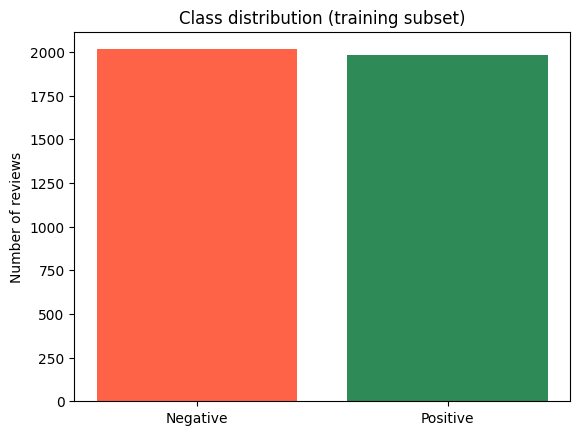

In [4]:
# Class distribution
labels, counts = np.unique(train_ds["label"], return_counts=True)
plt.bar(["Negative", "Positive"], counts, color=["tomato", "seagreen"])
plt.title("Class distribution (training subset)")
plt.ylabel("Number of reviews")
plt.show()

## 3. Tokenization
BERT needs input as token IDs plus an attention mask. We truncate reviews to 256 tokens.

In [5]:
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

train_tok = train_ds.map(tokenize, batched=True)
test_tok  = test_ds.map(tokenize, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)  # pads dynamically per batch
print(tokenizer.convert_ids_to_tokens(train_tok[0]["input_ids"][:15]))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

['[CLS]', 'there', 'is', 'no', 'relation', 'at', 'all', 'between', 'fort', '##ier', 'and', 'profile', '##r', 'but', 'the']


## 4. Load pre-trained BERT with a classification head

In [6]:
id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {"NEGATIVE": 0, "POSITIVE": 1}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, id2label=id2label, label2id=label2id
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 5. Fine-tune the model

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    return {"accuracy": accuracy_score(labels, preds),
            "precision": precision, "recall": recall, "f1": f1}

import inspect, transformers
print("transformers version:", transformers.__version__)

ta_params = inspect.signature(TrainingArguments.__init__).parameters
eval_key = "eval_strategy" if "eval_strategy" in ta_params else "evaluation_strategy"

training_args = TrainingArguments(
    output_dir="bert-sentiment",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to="none",
    **{eval_key: "epoch"},
)

tok_key = "processing_class" if "processing_class" in inspect.signature(Trainer.__init__).parameters else "tokenizer"

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=test_tok,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    **{tok_key: tokenizer},
)

trainer.train()

transformers version: 5.18.0


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.187832,0.335866,0.886000,0.910088,0.850410,0.879237
2,0.107766,0.437680,0.891000,0.881288,0.897541,0.889340


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=500, training_loss=0.1511240711212158, metrics={'train_runtime': 162.9906, 'train_samples_per_second': 49.083, 'train_steps_per_second': 3.068, 'total_flos': 1052444221440000.0, 'train_loss': 0.1511240711212158, 'epoch': 2.0})

## 6. Evaluate

In [9]:
results = trainer.evaluate()
for k, v in results.items():
    if k.startswith("eval_") and isinstance(v, float):
        print(f"{k[5:]:>10}: {v:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.107766,0.437680,2,0.891000,0.881288,0.897541,0.889340


      loss: 0.4377
  accuracy: 0.8910
 precision: 0.8813
    recall: 0.8975
        f1: 0.8893


              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89       512
    Positive       0.88      0.90      0.89       488

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



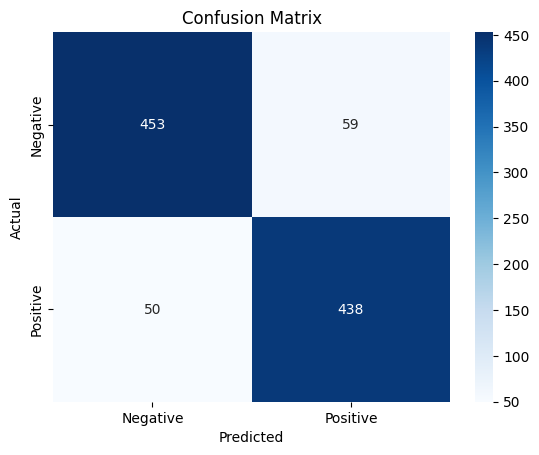

In [10]:
pred_out = trainer.predict(test_tok)
y_pred = np.argmax(pred_out.predictions, axis=-1)
y_true = pred_out.label_ids

print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

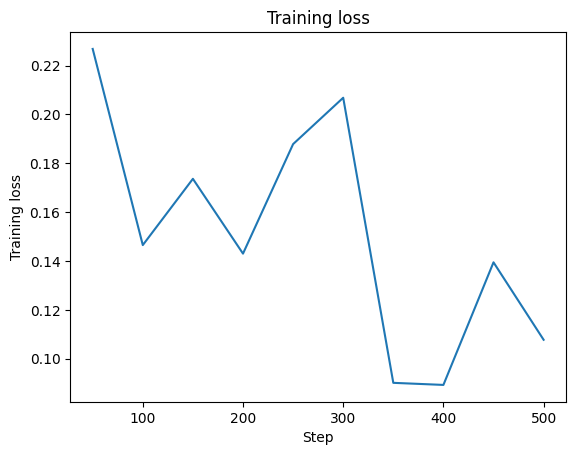

In [11]:
logs = [l for l in trainer.state.log_history if "loss" in l]
plt.plot([l["step"] for l in logs], [l["loss"] for l in logs])
plt.xlabel("Step"); plt.ylabel("Training loss"); plt.title("Training loss"); plt.show()

## 7. Predict sentiment on new text

In [12]:
def predict_sentiment(texts):
    if isinstance(texts, str):
        texts = [texts]
    inputs = tokenizer(texts, return_tensors="pt", truncation=True,
                       max_length=MAX_LEN, padding=True).to(model.device)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(**inputs).logits, dim=-1).cpu().numpy()
    for text, p in zip(texts, probs):
        print(f"{id2label[int(p.argmax())]:8s} ({p.max():.2%})  |  {text}")

predict_sentiment([
    "This movie was absolutely fantastic, I loved every minute of it!",
    "Terrible plot, bad acting, and a complete waste of time.",
    "It was okay, nothing special but not bad either.",
])

POSITIVE (99.65%)  |  This movie was absolutely fantastic, I loved every minute of it!
NEGATIVE (99.80%)  |  Terrible plot, bad acting, and a complete waste of time.
POSITIVE (55.98%)  |  It was okay, nothing special but not bad either.


## 8. Save the model (optional)

In [13]:
trainer.save_model("bert-sentiment-final")
tokenizer.save_pretrained("bert-sentiment-final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert-sentiment-final/tokenizer_config.json',
 'bert-sentiment-final/tokenizer.json')

## Conclusion
- Fine-tuned `bert-base-uncased` on a subset of IMDb reviews for binary sentiment classification.
- BERT's contextual embeddings capture negation and context, which is why it typically beats bag-of-words models (about 90% accuracy is common even on this small subset).
- **Improvements:** use the full dataset, increase `MAX_LEN`, train more epochs, or try RoBERTa/DistilBERT.